# Sustainability Report Text Extraction

This notebook extracts raw textual data from the sustainability
reports of the 25 FTSE 100 companies included in the study.

PyMuPDF is used for PDF text extraction. Original PDF files are
preserved unchanged and extracted text is written to a separate
directory.

In [1]:
%pip install pymupdf
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Libraries 

from pathlib import Path
import fitz

## 1. Single-document extraction test

The extraction procedure is initially tested using C01 to verify
that PDF text can be recovered correctly before batch processing
the complete corpus.

In [3]:


pdf_path = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Sustainability_Reports\C01_Vodafone_2025.pdf"
)

print("File exists:", pdf_path.exists())
print("Path:", pdf_path)

document = fitz.open(pdf_path)

print("PDF opened successfully")
print("Number of pages:", len(document))

pages = []

for page_number, page in enumerate(document, start=1):
    text = page.get_text("text")
    pages.append(text)

document.close()

raw_text = "\n\n".join(pages)

print("Characters extracted:", len(raw_text))
print("Approximate words extracted:", len(raw_text.split()))

print("\n--- TEXT PREVIEW ---\n")
print(raw_text[:2000])

File exists: True
Path: C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Sustainability_Reports\C01_Vodafone_2025.pdf
PDF opened successfully
Number of pages: 24
Characters extracted: 150369
Approximate words extracted: 21841

--- TEXT PREVIEW ---

30
Vodafone Group Plc Annual Report 2025 
Strategic report
Governance
Financials
Other information
Purpose, sustainability and responsible business
Everyone.Connected
We address Environmental, Social 
and Governance (‘ESG’) topics through 
our purpose strategy, with the goal  
of enabling an inclusive, sustainable 
and trusted digital society.
This year we continued to simplify, evolve and 
embed our purpose strategy across our business, 
with a focus on ‘Protecting the Planet’ and 
‘Empowering People’ in a digital society. These 
pillars are underpinned by our commitment  
of ‘Maintaining Trust’ in everything we do. 
ESG highlights1
76% 
4G population 
coverage (outdoor 
1Mbps) in Africa 
77.1m 
customers 
connected to  
our financial

## 2. Batch Extraction of Sustainability Reports

Following successful validation of the single-document extraction procedure using C01, the extraction process is now applied consistently to the complete sample of 25 FTSE 100 companies.

All source documents have been standardised to contain only sustainability-related disclosure. Therefore, the complete content of each PDF is extracted.

The procedure:

1. identifies all PDF files in the sustainability-report directory;
2. extracts text from every page using PyMuPDF;
3. preserves page boundaries within the raw textual output;
4. saves one raw text file for each company;
5. records document-level extraction statistics; and
6. produces an extraction audit dataset for quality-control purposes.

The original PDF files remain unchanged throughout the process.

In [4]:
from pathlib import Path
import re

import fitz
import pandas as pd


# ---------------------------------------------------------
# PROJECT PATHS
# ---------------------------------------------------------

PDF_DIR = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Sustainability_Reports"
)

OUTPUT_DIR = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Extracted_Text"
)

# Create the output folder automatically if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


print("PDF folder exists:", PDF_DIR.exists())
print("Output folder:", OUTPUT_DIR)

PDF folder exists: True
Output folder: C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Extracted_Text


### 2.1 Source File Validation

Before extraction, the PDF directory is checked to confirm that the expected 25 sustainability reports are present and that each document follows the predefined C01–C25 identifier convention.

This validation reduces the risk of missing documents, duplicate reports, or incorrect company identifiers entering the analytical corpus.

In [5]:
# check the 25 company files 

pdf_files = sorted(PDF_DIR.glob("*.pdf"))

print("Number of PDF files found:", len(pdf_files))
print()

for pdf in pdf_files:
    print(pdf.name)

Number of PDF files found: 25

C01_Vodafone_2025.pdf
C02_British_American_Tobacco_2025.pdf
C03_Diageo_2025.pdf
C04_SEGRO_2025.pdf
C05_Bunzl_2025.pdf
C06_GSK_2025.pdf
C07_Unilever_2025.pdf
C08_Tesco_2025.pdf
C09_BAE_Systems_2025.pdf
C10_Shell_2025.pdf
C11_HSBC_2025.pdf
C12_AstraZeneca_2025.pdf
C13_BP_2025.pdf
C14_Legal_and_General_2025.pdf
C15_Lloyds_Banking_Group_2025.pdf
C16_Barclays_2025.pdf
C17_RELX_2025.pdf
C18_Computacenter_2025.pdf
C19_Glencore_2025.pdf
C20_Compass_Group_2025.pdf
C21_Rolls_Royce_2025.pdf
C22_National_Grid_2025.pdf
C23_SSE_2025.pdf
C24_Anglo_American_2025.pdf
C25_Rio_Tinto_2025.pdf


In [6]:
# check for duplicate file IDs 

def extract_company_id(filename):
    """
    Extract an identifier such as C01 from a standardised filename.
    """
    match = re.match(r"^(C\d{2})_", filename)

    if match:
        return match.group(1)

    return None


company_ids = [extract_company_id(pdf.name) for pdf in pdf_files]

expected_ids = [f"C{i:02d}" for i in range(1, 26)]

missing_ids = sorted(set(expected_ids) - set(company_ids))
unexpected_ids = sorted(set(company_ids) - set(expected_ids))
duplicate_ids = sorted(
    {
        company_id
        for company_id in company_ids
        if company_ids.count(company_id) > 1
    }
)


print("Expected reports:", len(expected_ids))
print("PDF reports found:", len(pdf_files))
print("Missing IDs:", missing_ids)
print("Unexpected IDs:", unexpected_ids)
print("Duplicate IDs:", duplicate_ids)

Expected reports: 25
PDF reports found: 25
Missing IDs: []
Unexpected IDs: []
Duplicate IDs: []


### 2.2 Raw Text Extraction

Each PDF is processed page by page. Text is extracted using PyMuPDF and retained in its raw form without linguistic preprocessing.

Page markers are inserted into the resulting text files to preserve document original source and facilitate later quality checks.

At this stage, headers, footers, page numbers, tables, punctuation and other document features are intentionally retained. Text cleaning is performed separately in a later preprocessing stage.

In [7]:
# 25 sample batch raw text extraction 

audit_records = []


for pdf_path in pdf_files:

    company_id = extract_company_id(pdf_path.name)

    print(f"Processing {company_id}: {pdf_path.name}")

    try:
        document = fitz.open(pdf_path)

        total_pages = len(document)

        extracted_pages = []
        empty_pages = 0

        for page_number, page in enumerate(document, start=1):

            page_text = page.get_text("text")

            # Count pages returning effectively no text
            if not page_text.strip():
                empty_pages += 1

            # Preserve page boundaries for future checking
            extracted_pages.append(
                f"\n\n--- PDF PAGE {page_number} ---\n\n"
                f"{page_text}"
            )

        document.close()

        # Combine all pages
        raw_text = "".join(extracted_pages)

        # Basic corpus statistics
        character_count = len(raw_text)

        word_count = len(raw_text.split())

        # Percentage of pages with no extracted text
        if total_pages > 0:
            empty_page_percentage = (
                empty_pages / total_pages
            ) * 100
        else:
            empty_page_percentage = 100

        # ---------------------------------------------
        # Preliminary extraction quality classification
        # ---------------------------------------------

        if word_count < 500:

            extraction_status = "REVIEW - VERY LOW TEXT"

        elif empty_page_percentage > 25:

            extraction_status = "REVIEW - MANY EMPTY PAGES"

        else:

            extraction_status = "PASS"

        # ---------------------------------------------
        # Save raw text
        # ---------------------------------------------

        output_filename = (
            pdf_path.stem + "_raw.txt"
        )

        output_path = OUTPUT_DIR / output_filename

        output_path.write_text(
            raw_text,
            encoding="utf-8"
        )

        # ---------------------------------------------
        # Save audit information
        # ---------------------------------------------

        audit_records.append(
            {
                "Company_ID": company_id,
                "PDF_File": pdf_path.name,
                "Total_Pages": total_pages,
                "Empty_Pages": empty_pages,
                "Empty_Page_Percentage": round(
                    empty_page_percentage, 2
                ),
                "Character_Count": character_count,
                "Raw_Word_Count": word_count,
                "Extraction_Status": extraction_status,
                "Raw_Text_File": output_filename,
            }
        )

    except Exception as error:

        print(
            f"ERROR processing {pdf_path.name}: {error}"
        )

        audit_records.append(
            {
                "Company_ID": company_id,
                "PDF_File": pdf_path.name,
                "Total_Pages": None,
                "Empty_Pages": None,
                "Empty_Page_Percentage": None,
                "Character_Count": None,
                "Raw_Word_Count": None,
                "Extraction_Status": f"ERROR: {error}",
                "Raw_Text_File": None,
            }
        )


print("\nBatch extraction completed.")

Processing C01: C01_Vodafone_2025.pdf
Processing C02: C02_British_American_Tobacco_2025.pdf
Processing C03: C03_Diageo_2025.pdf
Processing C04: C04_SEGRO_2025.pdf
Processing C05: C05_Bunzl_2025.pdf
Processing C06: C06_GSK_2025.pdf
Processing C07: C07_Unilever_2025.pdf
Processing C08: C08_Tesco_2025.pdf
Processing C09: C09_BAE_Systems_2025.pdf
Processing C10: C10_Shell_2025.pdf
Processing C11: C11_HSBC_2025.pdf
Processing C12: C12_AstraZeneca_2025.pdf
Processing C13: C13_BP_2025.pdf
Processing C14: C14_Legal_and_General_2025.pdf
Processing C15: C15_Lloyds_Banking_Group_2025.pdf
Processing C16: C16_Barclays_2025.pdf
Processing C17: C17_RELX_2025.pdf
Processing C18: C18_Computacenter_2025.pdf
Processing C19: C19_Glencore_2025.pdf
Processing C20: C20_Compass_Group_2025.pdf
Processing C21: C21_Rolls_Royce_2025.pdf
Processing C22: C22_National_Grid_2025.pdf
Processing C23: C23_SSE_2025.pdf
Processing C24: C24_Anglo_American_2025.pdf
Processing C25: C25_Rio_Tinto_2025.pdf

Batch extraction co

### 2.3 Extraction Audit

To assess corpus quality and support reproducibility, document-level extraction statistics are recorded for each company.

The audit captures the number of PDF pages, number and proportion of pages returning no extractable text, character count, raw word count and an initial extraction-status indicator.

These measures are used only for quality assurance at this stage and do not represent the final cleaned corpus statistics.

In [8]:
# the audit dataframe  

audit_df = pd.DataFrame(audit_records)

audit_df = audit_df.sort_values(
    by="Company_ID"
).reset_index(drop=True)

audit_df

,Company_ID,PDF_File,Total_Pages,Empty_Pages,Empty_Page_Percentage,Character_Count,Raw_Word_Count,Extraction_Status,Raw_Text_File
0,C01,C01_Vodafone_2025.pdf,24,0,0.00,150866,21961,PASS,C01_Vodafone_2025_raw.txt
1,C02,C02_British_American_Tobacco_2025.pdf,104,0,0.00,384546,55372,PASS,C02_British_American_Tobacco_2025_raw.txt
2,C03,C03_Diageo_2025.pdf,71,0,0.00,240141,37684,PASS,C03_Diageo_2025_raw.txt
3,C04,C04_SEGRO_2025.pdf,70,0,0.00,252378,36998,PASS,C04_SEGRO_2025_raw.txt
4,C05,C05_Bunzl_2025.pdf,16,0,0.00,65690,9479,PASS,C05_Bunzl_2025_raw.txt
5,C06,C06_GSK_2025.pdf,37,1,2.70,152968,23046,PASS,C06_GSK_2025_raw.txt
6,C07,C07_Unilever_2025.pdf,67,0,0.00,385311,56099,PASS,C07_Unilever_2025_raw.txt
7,C08,C08_Tesco_2025.pdf,61,0,0.00,193518,29810,PASS,C08_Tesco_2025_raw.txt
8,C09,C09_BAE_Systems_2025.pdf,15,0,0.00,62644,9210,PASS,C09_BAE_Systems_2025_raw.txt
9,C10,C10_Shell_2025.pdf,94,0,0.00,548076,79426,PASS,C10_Shell_2025_raw.txt


In [9]:
# save audit as CSV file 

audit_csv_path = OUTPUT_DIR / "extraction_audit.csv"

audit_df.to_csv(
    audit_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print("Audit saved to:")
print(audit_csv_path)

Audit saved to:
C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Extracted_Text\extraction_audit.csv


In [10]:
# Summary statistics 

print("EXTRACTION SUMMARY")
print("-" * 50)

print("Reports processed:", len(audit_df))

print(
    "Reports passed:",
    (audit_df["Extraction_Status"] == "PASS").sum()
)

print(
    "Reports requiring review:",
    (
        audit_df["Extraction_Status"] != "PASS"
    ).sum()
)

print(
    "Total pages:",
    audit_df["Total_Pages"].sum()
)

print(
    "Total raw words:",
    audit_df["Raw_Word_Count"].sum()
)

print(
    "Mean raw words per report:",
    round(
        audit_df["Raw_Word_Count"].mean(),
        0
    )
)

print(
    "Median raw words per report:",
    round(
        audit_df["Raw_Word_Count"].median(),
        0
    )
)

print(
    "Shortest report:",
    audit_df.loc[
        audit_df["Raw_Word_Count"].idxmin(),
        ["Company_ID", "Raw_Word_Count"]
    ].to_dict()
)

print(
    "Longest report:",
    audit_df.loc[
        audit_df["Raw_Word_Count"].idxmax(),
        ["Company_ID", "Raw_Word_Count"]
    ].to_dict()
)

EXTRACTION SUMMARY
--------------------------------------------------
Reports processed: 25
Reports passed: 25
Reports requiring review: 0
Total pages: 1372
Total raw words: 807482
Mean raw words per report: 32299.0
Median raw words per report: 25307.0
Shortest report: {'Company_ID': 'C22', 'Raw_Word_Count': 3006}
Longest report: {'Company_ID': 'C15', 'Raw_Word_Count': 101578}


In [11]:
# look for any issues with extraction 

review_df = audit_df[
    audit_df["Extraction_Status"] != "PASS"
]

if review_df.empty:

    print("All 25 reports passed the preliminary extraction check.")

else:

    print("The following reports require manual review:")

    display(review_df)

All 25 reports passed the preliminary extraction check.


###  Preliminary Extraction Assessment

The extraction audit will be reviewed before any text preprocessing is undertaken. Reports flagged because of unusually low extracted text or a high proportion of empty pages will be inspected individually against the original PDF.

Only after satisfactory extraction has been confirmed across the complete sample will the corpus progress to text-cleaning and NLP-specific preprocessing.

### 2.4 Final Corpus Quality-Control Review

Following manual standardisation of the source documents to sustainability-specific disclosure, the complete corpus was re-extracted. The revised corpus comprised 25 documents, 1,372 pages and approximately 807,482 raw words.

Document length remained heterogeneous, reflecting differences in corporate sustainability-reporting practices. Before preprocessing, the shortest and longest documents were manually reviewed to confirm that their observed lengths represented genuine differences in disclosure rather than extraction errors or inconsistent document scope.

In [12]:
audit_df["Words_Per_Page"] = (
    audit_df["Raw_Word_Count"] /
    audit_df["Total_Pages"]
).round(1)

In [13]:
# Review shortest and longest documents

extreme_reports = audit_df[
    audit_df["Company_ID"].isin(["C15", "C22"])
][
    [
        "Company_ID",
        "PDF_File",
        "Total_Pages",
        "Empty_Pages",
        "Raw_Word_Count",
        "Words_Per_Page",
        "Extraction_Status"
    ]
]

display(extreme_reports)

,Company_ID,PDF_File,Total_Pages,Empty_Pages,Raw_Word_Count,Words_Per_Page,Extraction_Status
14,C15,C15_Lloyds_Banking_Group_2025.pdf,145,0,101578,700.5,PASS
21,C22,C22_National_Grid_2025.pdf,8,0,3006,375.8,PASS


In [14]:
display(
    audit_df[
        [
            "Company_ID",
            "Total_Pages",
            "Raw_Word_Count",
            "Words_Per_Page"
        ]
    ].sort_values(
        "Raw_Word_Count",
        ascending=False
    )
)

,Company_ID,Total_Pages,Raw_Word_Count,Words_Per_Page
14,C15,145,101578,700.5
23,C24,165,91850,556.7
9,C10,94,79426,845.0
6,C07,67,56099,837.3
1,C02,104,55372,532.4
22,C23,49,41457,846.1
2,C03,71,37684,530.8
3,C04,70,36998,528.5
13,C14,60,31675,527.9
7,C08,61,29810,488.7


### 2.6 Raw Corpus Validation Outcome

All 25 sustainability reports successfully passed the extraction and quality-control procedures.

Following manual standardisation of the source documents, the final raw corpus comprised 1,372 pages and approximately 807,482 extracted words. Document lengths varied substantially across companies, reflecting differences in the extent and format of corporate sustainability disclosure.

The longest document (C15) contained 145 pages and 101,578 raw words, equivalent to approximately 700.5 words per page. The shortest document (C22) contained eight pages and 3,006 raw words, equivalent to approximately 375.8 words per page. Manual review confirmed that these differences reflected genuine variation in document scope rather than extraction failure.

The validated raw-text files are retained unchanged as the source corpus for subsequent preprocessing and NLP analysis.

# 3. Text Cleaning and NLP Preprocessing

Following validation of the raw textual corpus, the sustainability disclosures are prepared for natural language processing.

The validated raw-text files are retained unchanged to preserve an auditable representation of the source documents. Preprocessing is performed on derived copies rather than modifying the original extracted corpus.

Because the NLP techniques employed in this study rely on different linguistic information, preprocessing is model-specific. Topic-modelling approaches may benefit from lexical normalisation and removal of low-information terms, whereas sentiment and transformer-based models require substantially more of the original linguistic context to be retained.

The preprocessing workflow therefore separates common document cleaning from subsequent model-specific transformations.

In [15]:
# importing libraries and defining folders 

from pathlib import Path
import re
import pandas as pd
from collections import Counter

RAW_TEXT_DIR = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Extracted_Text"
)

CLEAN_TEXT_DIR = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Cleaned_Text"
)

CLEAN_TEXT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Raw text folder exists:", RAW_TEXT_DIR.exists())
print("Clean text folder:", CLEAN_TEXT_DIR)

Raw text folder exists: True
Clean text folder: C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Cleaned_Text


## 3.1 Conservative Master Cleaning

A conservative cleaning procedure is applied to the extracted sustainability disclosures before model-specific preprocessing.

The purpose of this stage is to remove high-confidence PDF extraction artefacts while preserving substantive sustainability language, numerical information, punctuation and contextual structure.

The master-cleaning procedure removes extraction-generated page markers, control characters, excessive whitespace, standalone website addresses and a limited set of clearly non-substantive document-navigation labels.

Note : No lowercasing, stop-word removal, stemming, lemmatisation or removal of sustainability terminology is performed at this stage.

In [16]:
# loading master-cleaning function 

def clean_master_text(text):
    """
    Conservative cleaning of sustainability-report text.

    Removes high-confidence PDF/document artefacts while preserving
    substantive ESG language, quantitative information, punctuation,
    headings and sentence context.
    """

    # 1. Remove extraction-generated page markers
    text = re.sub(
        r"--- PDF PAGE \d+ ---",
        " ",
        text
    )

    # 2. Character normalisation
    text = text.replace("\x00", " ")
    text = text.replace("\u00a0", " ")

    # 3. Remove standalone website addresses
    text = re.sub(
        r"(?im)^\s*(?:https?://)?(?:www\.)?"
        r"[A-Za-z0-9.-]+\.(?:com|org|net|co\.uk)"
        r"(?:/[^\s]*)?\s*$",
        " ",
        text
    )

    # 4. Remove only high-confidence navigation labels
    navigation_labels = {
        "Strategic report",
        "Financials",
        "Other information",
    }

    cleaned_lines = []

    for line in text.splitlines():

        stripped = line.strip()

        if stripped not in navigation_labels:
            cleaned_lines.append(line)

    text = "\n".join(cleaned_lines)

    # 5. Normalise horizontal whitespace
    text = re.sub(
        r"[ \t]+",
        " ",
        text
    )

    # 6. Remove spaces immediately before punctuation
    text = re.sub(
        r"\s+([,.;:!?])",
        r"\1",
        text
    )

    # 7. Reduce excessive blank lines
    text = re.sub(
        r"\n\s*\n\s*\n+",
        "\n\n",
        text
    )

    # 8. Remove unnecessary spaces at line boundaries
    text = "\n".join(
        line.strip()
        for line in text.splitlines()
    )

    return text.strip()

## 3.2 Single-Document Cleaning Validation

Before applying the cleaning procedure to the complete corpus, the process is tested using C01.

The raw and cleaned versions are compared to confirm that extraction artefacts are removed without materially altering substantive ESG disclosures.

In [17]:
# test-validate cleaning process

c01_raw_path = (
    RAW_TEXT_DIR /
    "C01_Vodafone_2025_raw.txt"
)

c01_raw = c01_raw_path.read_text(
    encoding="utf-8"
)

c01_clean = clean_master_text(
    c01_raw
)

print("RAW CHARACTERS:", len(c01_raw))
print("CLEAN CHARACTERS:", len(c01_clean))

reduction = (
    (len(c01_raw) - len(c01_clean))
    / len(c01_raw)
) * 100

print(
    "CHARACTER REDUCTION:",
    round(reduction, 2),
    "%"
)

print("\n--- CLEAN TEXT PREVIEW ---\n")
print(c01_clean[:3000])

RAW CHARACTERS: 150866
CLEAN CHARACTERS: 145399
CHARACTER REDUCTION: 3.62 %

--- CLEAN TEXT PREVIEW ---

30
Vodafone Group Plc Annual Report 2025
Governance
Purpose, sustainability and responsible business
Everyone.Connected
We address Environmental, Social
and Governance (‘ESG’) topics through
our purpose strategy, with the goal
of enabling an inclusive, sustainable
and trusted digital society.
This year we continued to simplify, evolve and
embed our purpose strategy across our business,
with a focus on ‘Protecting the Planet’ and
‘Empowering People’ in a digital society. These
pillars are underpinned by our commitment
of ‘Maintaining Trust’ in everything we do.
ESG highlights1
76%
4G population
coverage (outdoor
1Mbps) in Africa
77.1m
customers
connected to
our financial
inclusion services
75%
5G population
coverage (outdoor
1Mbps) in Europe
100%
network equipment
e-waste reused,
resold or sent
for recycling
100%
grid electricity
purchased and
used globally
matched with
renewable sou

## 3.3 Repeated-Line Diagnostic

Repeated lines are examined as a diagnostic step because corporate reports may contain recurring page headers, footers and navigation elements.

Frequency is not used as an automatic deletion criterion. Repeated sustainability concepts, section headings and quantitative indicators may represent legitimate disclosure and are therefore retained unless clearly identified as non-substantive document artefacts.

In [18]:
# check for repeated lines in report C01

lines = [
    line.strip()
    for line in c01_clean.splitlines()
    if line.strip()
]

line_counts = Counter(lines)

repeated_lines = [
    (line, count)
    for line, count in line_counts.items()
    if count >= 3
]

repeated_lines = sorted(
    repeated_lines,
    key=lambda x: x[1],
    reverse=True
)

print("REPEATED LINES IN C01")
print("-" * 60)

for line, count in repeated_lines[:50]:
    print(f"{count:>3} ×  {line}")

REPEATED LINES IN C01
------------------------------------------------------------
 27 ×  Governance
 24 ×  Vodafone Group Plc Annual Report 2025
 16 ×  Million tonnes CO2e
 11 ×  Notes:
 10 ×  Our approach continued
  8 ×  0.01
  6 ×  Maintaining Trust
  6 ×  Vodafone
  6 ×  %
  6 ×  –
  6 ×  million tonnes CO2e
  5 ×  Protecting the Planet
  5 ×  Empowering People
  5 ×  Human rights
  5 ×  Responsible supply chain
  5 ×  Code of Conduct
  5 ×  Speak Up
  5 ×  Risk management
  4 ×  75%
  4 ×  Health and safety
  4 ×  Protecting the Planet continued
  4 ×  2025
  4 ×  0.27
  4 ×  0.26
  4 ×  0.00
  4 ×  Group
  3 ×  100%
  3 ×  Workplace equality
  3 ×  page 53
  3 ×  page 42
  3 ×  Anti-bribery, corruption and fraud
  3 ×  page 43
  3 ×  page 45
  3 ×  2024
  3 ×  2%
  3 ×  0%
  3 ×  Find out more
  3 ×  6%


## 3.4 Corpus-Wide Master Cleaning

Following successful validation of the cleaning procedure using C01, the same conservative cleaning rules are applied consistently to all 25 sustainability reports.

Each cleaned document is saved separately, while the original raw-text corpus remains unchanged. A cleaning audit is also created to record document-level changes in word counts.

In [19]:
# clean all 25 reports 

cleaning_records = []

raw_files = sorted(
    RAW_TEXT_DIR.glob("C*_raw.txt")
)

print("Raw text files found:", len(raw_files))


for file_path in raw_files:

    company_id = file_path.name[:3]

    raw_text = file_path.read_text(
        encoding="utf-8"
    )

    cleaned_text = clean_master_text(
        raw_text
    )

    clean_filename = (
        file_path.stem
        .replace("_raw", "_clean")
        + ".txt"
    )

    clean_path = (
        CLEAN_TEXT_DIR /
        clean_filename
    )

    clean_path.write_text(
        cleaned_text,
        encoding="utf-8"
    )

    raw_words = len(
        raw_text.split()
    )

    clean_words = len(
        cleaned_text.split()
    )

    words_removed = (
        raw_words - clean_words
    )

    reduction_pct = (
        words_removed / raw_words * 100
        if raw_words > 0
        else 0
    )

    cleaning_records.append(
        {
            "Company_ID": company_id,
            "Raw_Text_File": file_path.name,
            "Clean_Text_File": clean_filename,
            "Raw_Word_Count": raw_words,
            "Clean_Word_Count": clean_words,
            "Words_Removed": words_removed,
            "Word_Reduction_Percentage": round(
                reduction_pct,
                2
            )
        }
    )


cleaning_audit = pd.DataFrame(
    cleaning_records
)

cleaning_audit = cleaning_audit.sort_values(
    "Company_ID"
).reset_index(drop=True)

display(cleaning_audit)

Raw text files found: 25


,Company_ID,Raw_Text_File,Clean_Text_File,Raw_Word_Count,Clean_Word_Count,Words_Removed,Word_Reduction_Percentage
0,C01,C01_Vodafone_2025_raw.txt,C01_Vodafone_2025_clean.txt,21961,21703,258,1.17
1,C02,C02_British_American_Tobacco_2025_raw.txt,C02_British_American_Tobacco_2025_clean.txt,55372,54836,536,0.97
2,C03,C03_Diageo_2025_raw.txt,C03_Diageo_2025_clean.txt,37684,37325,359,0.95
3,C04,C04_SEGRO_2025_raw.txt,C04_SEGRO_2025_clean.txt,36998,36632,366,0.99
4,C05,C05_Bunzl_2025_raw.txt,C05_Bunzl_2025_clean.txt,9479,9399,80,0.84
5,C06,C06_GSK_2025_raw.txt,C06_GSK_2025_clean.txt,23046,22861,185,0.80
6,C07,C07_Unilever_2025_raw.txt,C07_Unilever_2025_clean.txt,56099,55763,336,0.60
7,C08,C08_Tesco_2025_raw.txt,C08_Tesco_2025_clean.txt,29810,29505,305,1.02
8,C09,C09_BAE_Systems_2025_raw.txt,C09_BAE_Systems_2025_clean.txt,9210,9114,96,1.04
9,C10,C10_Shell_2025_raw.txt,C10_Shell_2025_clean.txt,79426,78954,472,0.59


In [20]:
# save the cleaning audit 

cleaning_audit_path = (
    CLEAN_TEXT_DIR /
    "cleaning_audit.csv"
)

cleaning_audit.to_csv(
    cleaning_audit_path,
    index=False,
    encoding="utf-8-sig"
)

print("Cleaning audit saved to:")
print(cleaning_audit_path)

Cleaning audit saved to:
C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Cleaned_Text\cleaning_audit.csv


## 3.5 Master Cleaning Summary

The master-cleaning audit is reviewed to assess the scale of textual modification introduced by the conservative preprocessing procedure.

A relatively modest reduction is expected because this stage is intended to remove extraction artefacts rather than linguistically transform the corpus.

In [21]:
# Summary statistics 

print("MASTER CLEANING SUMMARY")
print("-" * 50)

print(
    "Documents cleaned:",
    len(cleaning_audit)
)

print(
    "Raw corpus words:",
    cleaning_audit[
        "Raw_Word_Count"
    ].sum()
)

print(
    "Clean corpus words:",
    cleaning_audit[
        "Clean_Word_Count"
    ].sum()
)

print(
    "Words removed:",
    cleaning_audit[
        "Words_Removed"
    ].sum()
)

overall_reduction = (
    cleaning_audit[
        "Words_Removed"
    ].sum()
    /
    cleaning_audit[
        "Raw_Word_Count"
    ].sum()
    * 100
)

print(
    "Overall word reduction:",
    round(overall_reduction, 2),
    "%"
)

MASTER CLEANING SUMMARY
--------------------------------------------------
Documents cleaned: 25
Raw corpus words: 807482
Clean corpus words: 800239
Words removed: 7243
Overall word reduction: 0.9 %


# 4. Text Segmentation and Analytical Unit Construction

Following conservative cleaning, the master corpus is segmented into smaller textual units before topic modelling.

Whole sustainability reports are unsuitable as the sole analytical units because individual reports contain multiple environmental, social and governance themes. Sentence-aware text chunks therefore provide a more granular representation of sustainability disclosure while retaining the company identifier of the originating document.

Each chunk remains linked to its source company, allowing topic and sentiment outputs to be subsequently aggregated to company level for comparison with LSEG ESG performance.

Chunking does not alter the company-level sample size of 25 firms; it creates textual analytical units within each company disclosure.

In [22]:
%pip install spacy

Note: you may need to restart the kernel to use updated packages.


In [23]:
%pip install click

Note: you may need to restart the kernel to use updated packages.


In [24]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------ --------------------------------- 2.1/12.8 MB 11.1 MB/s eta 0:00:01
     -------------- ------------------------- 4.7/12.8 MB 11.7 MB/s eta 0:00:01
     ---------------------- ----------------- 7.1/12.8 MB 11.6 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 11.6 MB/s eta 0:00:01
     ----------------------------------- --- 11.8/12.8 MB 11.5 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 11.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 10.3 MB/s  0:00:01
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 4.1 Sentence-Aware Chunking

The cleaned sustainability disclosures are divided into sentence-aware chunks rather than arbitrary character blocks.

A target size of approximately 300 words is used. This provides sufficient contextual information for topic modelling while keeping individual textual units reasonably focused.

Sentence boundaries are preserved wherever possible, reducing the risk of splitting sustainability statements midway through a sentence.

In [25]:
# import pandas, spacy and pathlib 

import spacy
import pandas as pd
from pathlib import Path

nlp = spacy.load(
    "en_core_web_sm",
    disable=["ner", "parser"]
)

# Add lightweight sentence segmentation
if "sentencizer" not in nlp.pipe_names:
    nlp.add_pipe("sentencizer")

print(nlp.pipe_names)

['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer', 'sentencizer']


In [26]:
# chunking function  

def create_sentence_chunks(text, target_words=300):
    """
    Divide text into sentence-aware chunks of approximately
    target_words words.

    Sentences remain intact wherever possible.
    """

    doc = nlp(text)

    chunks = []
    current_sentences = []
    current_word_count = 0

    for sentence in doc.sents:

        sentence_text = sentence.text.strip()

        if not sentence_text:
            continue

        sentence_words = len(
            sentence_text.split()
        )

        # If adding this sentence would exceed target size,
        # save the existing chunk first.
        if (
            current_sentences
            and current_word_count + sentence_words > target_words
        ):

            chunks.append(
                " ".join(current_sentences)
            )

            current_sentences = []
            current_word_count = 0

        current_sentences.append(
            sentence_text
        )

        current_word_count += sentence_words

    # Save final remaining chunk
    if current_sentences:

        chunks.append(
            " ".join(current_sentences)
        )

    return chunks

In [27]:
def create_sentence_chunks(text, target_words=300, max_words=350):
    """
    Create sentence-aware chunks with a target size of approximately
    300 words and a hard maximum of 350 words.

    Long sentence-like units caused by PDF formatting are split
    safely when they exceed the maximum size.
    """

    doc = nlp(text)

    chunks = []
    current_words = []

    for sentence in doc.sents:

        sentence_text = sentence.text.strip()

        if not sentence_text:
            continue

        sentence_words = sentence_text.split()

        # Handle unusually long sentence-like units
        while len(sentence_words) > max_words:

            if current_words:
                chunks.append(" ".join(current_words))
                current_words = []

            chunks.append(
                " ".join(sentence_words[:max_words])
            )

            sentence_words = sentence_words[max_words:]

        # Start a new chunk when target size would be exceeded
        if (
            current_words
            and
            len(current_words) + len(sentence_words) > target_words
        ):
            chunks.append(
                " ".join(current_words)
            )

            current_words = []

        current_words.extend(sentence_words)

    # Save remaining text
    if current_words:
        chunks.append(
            " ".join(current_words)
        )

    return chunks

In [28]:
from pathlib import Path

CLEAN_TEXT_DIR = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Cleaned_Text"
)

print("Clean text folder exists:", CLEAN_TEXT_DIR.exists())
print("Clean text folder:", CLEAN_TEXT_DIR)

Clean text folder exists: True
Clean text folder: C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Cleaned_Text


In [29]:
# chunking test using C01

c01_clean_path = (
    CLEAN_TEXT_DIR /
    "C01_Vodafone_2025_clean.txt"
)

c01_text = c01_clean_path.read_text(
    encoding="utf-8"
)

c01_chunks = create_sentence_chunks(
    c01_text,
    target_words=300
)

print("C01 chunks created:", len(c01_chunks))

chunk_lengths = [
    len(chunk.split())
    for chunk in c01_chunks
]

print(
    "Mean words per chunk:",
    round(
        sum(chunk_lengths) /
        len(chunk_lengths),
        1
    )
)

print(
    "Shortest chunk:",
    min(chunk_lengths)
)

print(
    "Longest chunk:",
    max(chunk_lengths)
)

print("\n--- FIRST CHUNK ---\n")
print(c01_chunks[0][:3000])



C01 chunks created: 76
Mean words per chunk: 285.6
Shortest chunk: 136
Longest chunk: 350

--- FIRST CHUNK ---

30 Vodafone Group Plc Annual Report 2025 Governance Purpose, sustainability and responsible business Everyone. Connected We address Environmental, Social and Governance (‘ESG’) topics through our purpose strategy, with the goal of enabling an inclusive, sustainable and trusted digital society. This year we continued to simplify, evolve and embed our purpose strategy across our business, with a focus on ‘Protecting the Planet’ and ‘Empowering People’ in a digital society. These pillars are underpinned by our commitment of ‘Maintaining Trust’ in everything we do. ESG highlights1 76% 4G population coverage (outdoor 1Mbps) in Africa 77.1m customers connected to our financial inclusion services 75% 5G population coverage (outdoor 1Mbps) in Europe 100% network equipment e-waste reused, resold or sent for recycling 100% grid electricity purchased and used globally matched with renew

## 4.2 Corpus-Wide Chunk Construction

Following successful validation of the revised sentence-aware chunking procedure using C01, the same segmentation method is applied to all 25 cleaned sustainability reports.

Each chunk retains the originating company identifier and receives a unique chunk identifier. This preserves traceability between model outputs, company-level disclosures and the original source reports.

A target length of approximately 300 words is used, with a maximum permitted chunk size of 350 words.

In [30]:
# corpus -wide chunk function 

chunk_records = []

clean_files = sorted(
    CLEAN_TEXT_DIR.glob("C*_clean.txt")
)

print("Clean text files found:", len(clean_files))


for file_path in clean_files:

    company_id = file_path.name[:3]

    text = file_path.read_text(
        encoding="utf-8"
    )

    chunks = create_sentence_chunks(
        text,
        target_words=300,
        max_words=350
    )

    for chunk_number, chunk_text in enumerate(
        chunks,
        start=1
    ):

        chunk_id = (
            f"{company_id}_CH{chunk_number:04d}"
        )

        chunk_records.append(
            {
                "Company_ID": company_id,
                "Chunk_ID": chunk_id,
                "Chunk_Number": chunk_number,
                "Word_Count": len(
                    chunk_text.split()
                ),
                "Text": chunk_text
            }
        )


chunks_df = pd.DataFrame(
    chunk_records
)

print(
    "Total chunks created:",
    len(chunks_df)
)

display(
    chunks_df.head()
)

Clean text files found: 25
Total chunks created: 2895


,Company_ID,Chunk_ID,Chunk_Number,Word_Count,Text
0,C01,C01_CH0001,1,296,30 Vodafone Group Plc Annual Report 2025 Gover...
1,C01,C01_CH0002,2,298,Empowering customers We strive to provide rele...
2,C01,C01_CH0003,3,300,Vodafone Group Plc Annual Report 2025 31 Gover...
3,C01,C01_CH0004,4,290,"In FY26, we aim to increase the frequency of j..."
4,C01,C01_CH0005,5,266,32 Vodafone Group Plc Annual Report 2025 Gover...


In [31]:
# Validate the chunks dataset 

print("CHUNKING SUMMARY")
print("-" * 50)

print(
    "Companies represented:",
    chunks_df["Company_ID"].nunique()
)

print(
    "Total chunks:",
    len(chunks_df)
)

print(
    "Mean words per chunk:",
    round(
        chunks_df["Word_Count"].mean(),
        1
    )
)

print(
    "Median words per chunk:",
    round(
        chunks_df["Word_Count"].median(),
        1
    )
)

print(
    "Shortest chunk:",
    chunks_df["Word_Count"].min()
)

print(
    "Longest chunk:",
    chunks_df["Word_Count"].max()
)


CHUNKING SUMMARY
--------------------------------------------------
Companies represented: 25
Total chunks: 2895
Mean words per chunk: 276.4
Median words per chunk: 286.0
Shortest chunk: 17
Longest chunk: 350


In [32]:
# chunk per company summary 

chunks_per_company = (
    chunks_df
    .groupby("Company_ID")
    .size()
    .reset_index(
        name="Number_of_Chunks"
    )
)

display(
    chunks_per_company
)

,Company_ID,Number_of_Chunks
0,C01,76
1,C02,199
2,C03,138
3,C04,133
4,C05,35
5,C06,82
6,C07,201
7,C08,107
8,C09,32
9,C10,283


In [33]:
# save the chunks dataset 

CHUNK_DIR = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Chunks"
)

CHUNK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

chunk_csv_path = (
    CHUNK_DIR /
    "sustainability_chunks.csv"
)

chunks_df.to_csv(
    chunk_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print("Chunk dataset saved to:")
print(chunk_csv_path)

Chunk dataset saved to:
C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Chunks\sustainability_chunks.csv


## 4.3 Chunk Quality Assessment

Following segmentation, chunk-length distributions are examined to identify unusually short analytical units.

Very short chunks may arise naturally at the end of documents or from short standalone sections. Rather than being removed automatically, their prevalence is assessed before determining whether a minimum analytical length should be applied.

In [34]:
# Distribution of chunk lengths

print("Chunks under 50 words:",
      (chunks_df["Word_Count"] < 50).sum())

print("Chunks under 100 words:",
      (chunks_df["Word_Count"] < 100).sum())

print("Chunks between 250 and 350 words:",
      ((chunks_df["Word_Count"] >= 250) &
       (chunks_df["Word_Count"] <= 350)).sum())

Chunks under 50 words: 8
Chunks under 100 words: 33
Chunks between 250 and 350 words: 2581


In [35]:
# inspect the shortest chunks 

short_chunks = (
    chunks_df
    .sort_values("Word_Count")
    .head(20)
)

display(
    short_chunks[
        [
            "Company_ID",
            "Chunk_ID",
            "Word_Count",
            "Text"
        ]
    ]
)

,Company_ID,Chunk_ID,Word_Count,Text
2056,C16,C16_CH0031,17,Carbon prices stay high but stabilise in early...
2894,C25,C25_CH0031,30,Sustainability Glossary 2025 11 Materiality de...
860,C07,C07_CH0198,36,(b) The sustainability statement is consistent...
858,C07,C07_CH0196,38,symbol (▲). (b) The sustainability statement i...
1976,C15,C15_CH0322,40,"Where approval is required, escalation is dire..."
2104,C17,C17_CH0033,42,While some RELX products and services will lea...
2514,C23,C23_CH0124,42,3 2024/25 data may be subject to minor adjustm...
1942,C15,C15_CH0288,48,Note the assets under management (AUM) of £187...
1880,C15,C15_CH0226,53,To enable us to better understand the home ret...
1835,C15,C15_CH0181,54,Banking activities continued Analysis by IFRS ...


# 5. LDA Preprocessing

Latent Dirichlet Allocation (LDA) requires a more structured preprocessing pipeline than the master-cleaned corpus.

The objective is to convert each analytical chunk into a list of meaningful linguistic tokens while removing terms that contribute little to topic identification.

The LDA preprocessing stage includes:

1. lowercasing;
2. tokenisation;
3. removal of punctuation and non-alphabetic tokens;
4. removal of stopwords;
5. lemmatisation;
6. removal of very short tokens;
7. preservation of meaningful sustainability terminology.

This preprocessing is applied only to the LDA branch. The master-cleaned corpus and the original analytical chunks remain unchanged for use in BERTopic, VADER and FinBERT.

In [36]:
 # Import libraries required for LDA preprocessing

import pandas as pd
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

print("Libraries imported successfully.")

Libraries imported successfully.


In [37]:
# Load the English spaCy model

try:
    nlp_lda = spacy.load(
        "en_core_web_sm",
        disable=[
            "parser",
            "ner"
        ]
    )

    print("spaCy model loaded successfully.")

except OSError:
    print(
        "spaCy model not found. "
        "Please install en_core_web_sm."
    )

spaCy model loaded successfully.


## 5.1 LDA Stopword Configuration

Standard English stopwords are removed because they occur frequently but contribute little to topic interpretation.

A limited set of generic corporate-reporting terms is also added. These terms are likely to appear across many reports regardless of sustainability theme and may otherwise dominate the topic model.

The customised list is intentionally conservative. Sustainability-specific terms such as *carbon*, *climate*, *emissions*, *energy*, *social*, *governance* and *sustainability* are retained.

In [38]:
# Create a conservative LDA stopword set

lda_stopwords = set(STOP_WORDS)

custom_report_stopwords = {
    "annual",
    "report",
    "page",
    "pages",
    "plc",
    "group",
    "company",
    "companies",
    "business",
    "year",
    "years",
    "including",
    "include",
    "included",
    "information",
    "section",
    "table",
    "figure"
}

lda_stopwords.update(custom_report_stopwords)

print("Total LDA stopwords:", len(lda_stopwords))
print("\nCustom report stopwords:")
print(sorted(custom_report_stopwords))

Total LDA stopwords: 344

Custom report stopwords:
['annual', 'business', 'companies', 'company', 'figure', 'group', 'include', 'included', 'including', 'information', 'page', 'pages', 'plc', 'report', 'section', 'table', 'year', 'years']


## 5.2 LDA Text Preprocessing

Each analytical chunk is converted into a sequence of lemmatised tokens suitable for topic modelling.

The preprocessing removes punctuation, stopwords, numbers and very short tokens while retaining meaningful sustainability terminology.

The resulting corpus forms the input for dictionary construction and topic modelling.

In [39]:
def preprocess_for_lda(text):
    """
    Preprocess one chunk for LDA topic modelling.
    Returns a list of cleaned tokens.
    """

    doc = nlp_lda(text)

    tokens = []

    for token in doc:

        lemma = token.lemma_.lower().strip()

        # Remove stopwords
        if lemma in lda_stopwords:
            continue

        # Remove punctuation and spaces
        if token.is_punct or token.is_space:
            continue

        # Remove numbers
        if token.like_num:
            continue

        # Keep alphabetic words only
        if not lemma.isalpha():
            continue

        # Remove very short words
        if len(lemma) < 3:
            continue

        tokens.append(lemma)

    return tokens

In [40]:
# Validate LDA preprocessing function with one Chunk 

sample_text = chunks_df.loc[0, "Text"]

sample_tokens = preprocess_for_lda(sample_text)

print("Number of tokens:", len(sample_tokens))

print("\nFirst 100 tokens:\n")

print(sample_tokens[:100])

Number of tokens: 153

First 100 tokens:

['vodafone', 'governance', 'purpose', 'sustainability', 'responsible', 'connected', 'address', 'environmental', 'social', 'governance', 'esg', 'topic', 'purpose', 'strategy', 'goal', 'enable', 'inclusive', 'sustainable', 'trust', 'digital', 'society', 'continue', 'simplify', 'evolve', 'embed', 'purpose', 'strategy', 'focus', 'protect', 'planet', 'empower', 'people', 'digital', 'society', 'pillar', 'underpin', 'commitment', 'maintaining', 'trust', 'esg', 'population', 'coverage', 'outdoor', 'africa', 'customer', 'connect', 'financial', 'inclusion', 'service', 'population', 'coverage', 'outdoor', 'europe', 'network', 'equipment', 'waste', 'reuse', 'resold', 'send', 'recycle', 'grid', 'electricity', 'purchase', 'use', 'globally', 'match', 'renewable', 'reduction', 'scope', 'ghg', 'emission', 'purpose', 'connect', 'aim', 'build', 'inclusive', 'sustainable', 'trust', 'digital', 'society', 'individual', 'thrive', 'protect', 'planet', 'help', 'protect

## 5.3 Corpus-Wide LDA Preprocessing

The validated preprocessing function was applied to all analytical chunks.

Each chunk was converted into a list of lemmatised tokens while the original chunk text and identifying metadata were retained. This preserves traceability between the topic-model input, the source company and the original sustainability disclosure.

In [41]:
# Apply LDA preprocessing to all analytical chunks

from tqdm.auto import tqdm

tqdm.pandas(desc="Preprocessing chunks")

chunks_df["LDA_Tokens"] = chunks_df["Text"].progress_apply(
    preprocess_for_lda
)

chunks_df["LDA_Token_Count"] = chunks_df["LDA_Tokens"].apply(len)

print("LDA preprocessing completed.")
print("Chunks processed:", len(chunks_df))

C:\Users\techi\.conda\envs\notebook-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Preprocessing chunks: 100%|██████████| 2895/2895 [03:02<00:00, 15.88it/s]

LDA preprocessing completed.
Chunks processed: 2895


In [42]:
# Summarise the corpus after LDA preprocessing

print("Chunks processed:", len(chunks_df))

print(
    "\nMean LDA tokens per chunk:",
    round(chunks_df["LDA_Token_Count"].mean(), 1)
)

print(
    "Median LDA tokens per chunk:",
    round(chunks_df["LDA_Token_Count"].median(), 1)
)

print(
    "Shortest preprocessed chunk:",
    chunks_df["LDA_Token_Count"].min()
)

print(
    "Longest preprocessed chunk:",
    chunks_df["LDA_Token_Count"].max()
)

print(
    "Chunks with zero tokens:",
    (chunks_df["LDA_Token_Count"] == 0).sum()
)

Chunks processed: 2895

Mean LDA tokens per chunk: 149.3
Median LDA tokens per chunk: 153.0
Shortest preprocessed chunk: 14
Longest preprocessed chunk: 277
Chunks with zero tokens: 0


### LDA Preprocessing Validation

LDA preprocessing was successfully applied to all 2,895 analytical chunks. The processed chunks contained an average of 149.3 tokens and a median of 153 tokens. Token counts ranged from 14 to 277.

No analytical chunks contained zero tokens following preprocessing. This indicates that the preprocessing procedure removed linguistic noise without eliminating the substantive content of any disclosure unit. Consequently, all 2,895 chunks were retained for subsequent topic modelling.

## 5.4 Detection of Multiword Expressions

Sustainability disclosures contain multiword concepts whose meanings are not fully represented by their individual words. Examples include *climate change*, *human rights*, *renewable energy* and *supply chain*.

Statistical phrase detection was therefore used to identify frequently co-occurring two-word expressions across the LDA corpus. Valid expressions were joined using an underscore so that they could be represented as single vocabulary terms during topic modelling.

Phrase detection was fitted exclusively to the LDA token corpus and did not modify the original analytical text.

In [43]:
 # check Genism is available 

try:
    import gensim
    from gensim.models.phrases import Phrases, Phraser

    print("Gensim version:", gensim.__version__)
    print("Phrase-detection tools imported successfully.")

except ImportError:
    print(
        "Gensim is not installed. Install it using: "
        "pip install gensim"
    )

Gensim version: 4.4.0
Phrase-detection tools imported successfully.


In [44]:
# Build a bigram phrase-detection model

lda_token_lists = chunks_df["LDA_Tokens"].tolist()

bigram_model = Phrases(
    lda_token_lists,
    min_count=5,
    threshold=10
)

bigram_phraser = Phraser(bigram_model)

print("Bigram phrase model created successfully.")

Bigram phrase model created successfully.


In [45]:
# Apply detected bigrams to every LDA token list

chunks_df["LDA_Bigram_Tokens"] = chunks_df["LDA_Tokens"].apply(
    lambda tokens: list(bigram_phraser[tokens])
)

chunks_df["LDA_Bigram_Token_Count"] = (
    chunks_df["LDA_Bigram_Tokens"].apply(len)
)

print("Bigram transformation completed.")
print("Chunks transformed:", len(chunks_df))

Bigram transformation completed.
Chunks transformed: 2895


In [46]:
# Identify the most frequent detected bigrams

from collections import Counter

all_bigram_tokens = [
    token
    for tokens in chunks_df["LDA_Bigram_Tokens"]
    for token in tokens
    if "_" in token
]

bigram_counts = Counter(all_bigram_tokens)

print("Number of unique detected bigrams:", len(bigram_counts))
print("\n30 most frequent detected bigrams:\n")

for phrase, frequency in bigram_counts.most_common(30):
    print(f"{phrase:<35} {frequency}")

Number of unique detected bigrams: 2903

30 most frequent detected bigrams:

supply_chain                        706
human_right                         615
value_chain                         572
climate_change                      539
long_term                           523
risk_opportunity                    507
climate_relate                      373
anglo_american                      373
scope_emission                      333
low_carbon                          331
ghg_emission                        322
sustainability_statement            285
support_transition                  275
health_safety                       265
local_community                     238
energy_transition                   207
climate_nature                      193
relate_disclosure                   190
greenhouse_gas                      185
human_rights                        185
nature_relate                       181
good_practice                       178
regional_development                176
acc

## 5.5 Removal of Company Identifiers

The objective of the LDA model is to identify common sustainability disclosure themes rather than distinguish individual organisations.

Consequently, company names and organisation-specific identifiers were removed from the LDA corpus following phrase detection. This prevents topics from being dominated by company identities while preserving sustainability-related terminology.

This preprocessing step was applied exclusively to the LDA corpus and did not modify the original analytical text.

In [47]:
# Company identifiers to remove from the LDA corpus

company_tokens = {

    # Single-word names
    "vodafone",
    "diageo",
    "segro",
    "bunzl",
    "gsk",
    "unilever",
    "tesco",
    "bae",
    "shell",
    "hsbc",
    "astrazeneca",
    "barclays",
    "relx",
    "computacenter",
    "glencore",
    "compass",
    "sse",
    "lloyds",

    # Generic corporate words
    "group",
    "holdings",
    "holding",
    "banking",

    # Words that become part of company names
    
    "british",
    "american",
    "anglo",
    "rio",
    "tinto",
    "rolls",
    "royce",

    # Leave "bp" OUT because it is only two characters
}

In [48]:
# Add company biagrams 

company_bigrams = {

    "british_american",
    "legal_general",
    "national_grid",
    "anglo_american",
    "rio_tinto",
    "rolls_royce"
}

In [49]:
# Remove company identifiers from every document

def remove_company_names(tokens):

    return [
        token
        for token in tokens
        if token not in company_tokens
        and token not in company_bigrams
    ]


chunks_df["LDA_Final_Tokens"] = (
    chunks_df["LDA_Bigram_Tokens"]
    .apply(remove_company_names)
)

chunks_df["LDA_Final_Token_Count"] = (
    chunks_df["LDA_Final_Tokens"]
    .apply(len)
)

print("Company identifiers removed successfully.")

Company identifiers removed successfully.


In [50]:
#validate 

print("Mean final token count:",
      round(chunks_df["LDA_Final_Token_Count"].mean(),1))

print("Zero-token documents:",
      (chunks_df["LDA_Final_Token_Count"]==0).sum())

Mean final token count: 127.9
Zero-token documents: 0


## 5.6 Dictionary Construction

The preprocessed corpus was converted into a dictionary of unique terms using the Gensim Dictionary class.

To improve topic quality, extremely rare terms and extremely common terms were removed. Rare words contribute little to stable topic formation, while very common words occur across most documents and provide limited discriminatory value.

The resulting dictionary forms the vocabulary used for Latent Dirichlet Allocation.

In [51]:
# import dictionary 

from gensim.corpora import Dictionary

# Create the dictionary
lda_dictionary = Dictionary(chunks_df["LDA_Final_Tokens"])

print("Initial vocabulary size:", len(lda_dictionary))

Initial vocabulary size: 14721


### Dictionary Frequency Filtering

The initial LDA dictionary contained 14,721 unique terms. Frequency filtering was applied to remove terms that were either too rare to support stable topic formation or too common to distinguish between topics.

Terms appearing in fewer than five analytical chunks were removed. Terms appearing in more than 50% of all chunks were also removed. These thresholds were selected conservatively to reduce vocabulary noise while retaining recurring sustainability concepts.

In [52]:
# Record the initial vocabulary size

initial_vocab_size = len(lda_dictionary)

# Remove extremely rare and extremely common terms

lda_dictionary.filter_extremes(
    no_below=5,
    no_above=0.50,
    keep_n=None
)

# Compact token IDs after filtering

lda_dictionary.compactify()

filtered_vocab_size = len(lda_dictionary)

print("Initial vocabulary size:", initial_vocab_size)
print("Filtered vocabulary size:", filtered_vocab_size)
print(
    "Terms removed:",
    initial_vocab_size - filtered_vocab_size
)
print(
    "Vocabulary retained:",
    f"{filtered_vocab_size / initial_vocab_size * 100:.1f}%"
)

Initial vocabulary size: 14721
Filtered vocabulary size: 6448
Terms removed: 8273
Vocabulary retained: 43.8%


### Dictionary Validation

The initial dictionary contained 14,721 unique terms. Following frequency-based filtering, 6,448 terms were retained for topic modelling.

Approximately 56.2% of the vocabulary was removed, consisting primarily of extremely rare or highly frequent terms. The retained vocabulary represents recurring sustainability concepts that provide meaningful discrimination between topics while reducing lexical noise.

## 5.7 Construction of the Document-Term Matrix

Each preprocessed analytical chunk was converted into a bag-of-words representation using the filtered dictionary.

The resulting document-term matrix records the frequency of each retained vocabulary term within every analytical unit and forms the input to the LDA model.

In [53]:
# Build the LDA corpus (document-term matrix)

lda_corpus = [
    lda_dictionary.doc2bow(tokens)
    for tokens in chunks_df["LDA_Final_Tokens"]
]

print("Number of documents:", len(lda_corpus))

print("\nExample bag-of-words representation:\n")

print(lda_corpus[0][:20])

Number of documents: 2895

Example bag-of-words representation:

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 2), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1)]


## 5.8 Topic Number Optimisation

The optimal number of topics was determined using topic coherence.

Rather than selecting an arbitrary number of topics, multiple LDA models were estimated across a range of topic numbers. The coherence score (c_v) was calculated for each model to evaluate semantic consistency.

The model with the highest coherence score was selected for the final analysis.

In [54]:
from gensim.models import LdaModel
from gensim.models import CoherenceModel

print("LDA and coherence tools imported successfully.")

LDA and coherence tools imported successfully.


In [55]:
def compute_coherence_values(
    dictionary,
    corpus,
    texts,
    start=5,
    limit=20,
    step=1
):
    """
    Train multiple LDA models and compute c_v coherence.
    """

    model_list = []
    coherence_values = []

    for num_topics in range(start, limit + 1, step):

        print(f"Training LDA model with {num_topics} topics...")

        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            chunksize=200,
            passes=10,
            alpha="auto",
            eta="auto"
        )

        model_list.append(model)

        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v"
        )

        coherence_values.append(
            coherence_model.get_coherence()
        )

    return model_list, coherence_values

In [56]:
# Run the optimization 

models, coherence_scores = compute_coherence_values(
    dictionary=lda_dictionary,
    corpus=lda_corpus,
    texts=chunks_df["LDA_Final_Tokens"],
    start=5,
    limit=20,
    step=1
)

Training LDA model with 5 topics...
Training LDA model with 6 topics...
Training LDA model with 7 topics...
Training LDA model with 8 topics...
Training LDA model with 9 topics...
Training LDA model with 10 topics...
Training LDA model with 11 topics...
Training LDA model with 12 topics...
Training LDA model with 13 topics...
Training LDA model with 14 topics...
Training LDA model with 15 topics...
Training LDA model with 16 topics...
Training LDA model with 17 topics...
Training LDA model with 18 topics...
Training LDA model with 19 topics...
Training LDA model with 20 topics...


In [57]:
# Display coherence scores

for k, score in zip(range(5, 21), coherence_scores):
    print(f"{k} topics: {score:.4f}")

5 topics: 0.4845
6 topics: 0.4747
7 topics: 0.4614
8 topics: 0.4490
9 topics: 0.4680
10 topics: 0.4653
11 topics: 0.4748
12 topics: 0.4715
13 topics: 0.4852
14 topics: 0.5144
15 topics: 0.4935
16 topics: 0.5083
17 topics: 0.4939
18 topics: 0.4854
19 topics: 0.5092
20 topics: 0.5079


In [58]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "matplotlib"
])

0

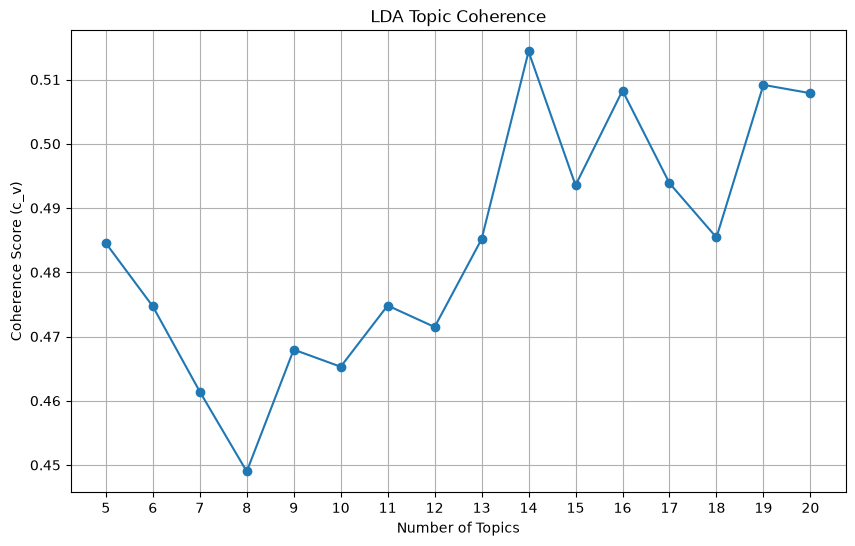

In [59]:
# Visualize the coherence score 

import matplotlib.pyplot as plt

topic_numbers = list(range(5, 21))

plt.figure(figsize=(10, 6))
plt.plot(topic_numbers, coherence_scores, marker="o")

plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("LDA Topic Coherence")

plt.xticks(topic_numbers)
plt.grid(True)

plt.show()

In [60]:
# Display coherence scores in descending order

coherence_results = pd.DataFrame({
    "Number_of_Topics": list(range(5, 21)),
    "Coherence_Score": coherence_scores
})

coherence_results = coherence_results.sort_values(
    by="Coherence_Score",
    ascending=False
).reset_index(drop=True)

coherence_results

,Number_of_Topics,Coherence_Score
0,14,0.514369
1,19,0.509172
2,16,0.508286
3,20,0.507878
4,17,0.493865
5,15,0.493546
6,18,0.485423
7,13,0.485162
8,5,0.484537
9,11,0.474822


In [61]:
best_row = coherence_results.iloc[0]

print("Highest coherence score:")
print(f"Topics: {int(best_row['Number_of_Topics'])}")
print(f"Coherence: {best_row['Coherence_Score']:.4f}")

Highest coherence score:
Topics: 14
Coherence: 0.5144


In [62]:
best_num_topics = 14
best_model_index = best_num_topics - 5

lda_model_14 = models[best_model_index]

print("Selected model:", lda_model_14.num_topics, "topics")

Selected model: 14 topics


In [63]:
topic_rows = []

for topic_id, terms in lda_model_14.show_topics(
    num_topics=14,
    num_words=15,
    formatted=False
):
    topic_rows.append({
        "Topic": topic_id + 1,
        "Top_Words": ", ".join([word for word, probability in terms])
    })

lda_topic_table = pd.DataFrame(topic_rows)

pd.set_option("display.max_colwidth", None)
lda_topic_table

,Topic,Top_Words
0,1,"risk, impact, management, risk_opportunity, climate_change, assessment, relate, material, exposure, assess, activity, climate, consider, manage, identify"
1,2,"support, community, programme, work, continue, help, focus, development, local, provide, initiative, improve, new, deliver, ensure"
2,3,"supplier, risk, human_right, policy, management, mining, standard, manage, process, supply_chain, approach, identify, operation, conduct, security"
3,4,"safety, work, health, incident, contractor, employee, worker, number, health_safety, case, workforce, consultation, employee_contractor, illness, record"
4,5,"assurance, stage, engagement, likely, prepare, limited_assurance, perform, field, select, likelihood, quarter, conclusion, procedure, test, professional"
5,6,"employee, colleague, people, training, workforce, skill, leadership, culture, employment, inclusion, role, pay, experience, engagement, mental_health"
6,7,"customer, investment, fund, sector, finance, deliver, job, support_transition, support, funding, home, market, financial, growth, sustainable"
7,8,"sustainability, board, relate_disclosure, governance, strategy, committee, supplement, review, performance, management, framework, gri_reference, stakeholder, responsible, level"
8,9,"target, emission, transition, carbon, net, reduce, progress, reduction, low_carbon, climate, scope, increase, plan, portfolio, sector"
9,10,"energy, electricity, power, renewable_energy, renewable, generation, energy_consumption, supply, energy_efficiency, property, storage, hydrogen, system, grid, governance_structure"


In [64]:
# create label topic table 

topic_labels = {
    1: "Climate Risk and Materiality Assessment",
    2: "Community Investment and Social Development",
    3: "Human Rights and Responsible Supply Chains",
    4: "Occupational Health and Safety",
    5: "External Assurance and Verification",
    6: "Workforce Development, Inclusion and Wellbeing",
    7: "Sustainable Finance and Transition Investment",
    8: "Sustainability Governance and Oversight",
    9: "Carbon Reduction and Net-Zero Transition",
    10: "Renewable Energy and Energy Systems",
    11: "ESG Reporting Standards and Material Disclosures",
    12: "Biodiversity, Water and Natural Capital",
    13: "Emissions Measurement and Reporting Methodology",
    14: "Resource Use, Waste and Operational Efficiency"
}

lda_topic_table["Topic_Label"] = lda_topic_table["Topic"].map(topic_labels)

lda_topic_table = lda_topic_table[
    ["Topic", "Topic_Label", "Top_Words"]
]

lda_topic_table

,Topic,Topic_Label,Top_Words
0,1,Climate Risk and Materiality Assessment,"risk, impact, management, risk_opportunity, climate_change, assessment, relate, material, exposure, assess, activity, climate, consider, manage, identify"
1,2,Community Investment and Social Development,"support, community, programme, work, continue, help, focus, development, local, provide, initiative, improve, new, deliver, ensure"
2,3,Human Rights and Responsible Supply Chains,"supplier, risk, human_right, policy, management, mining, standard, manage, process, supply_chain, approach, identify, operation, conduct, security"
3,4,Occupational Health and Safety,"safety, work, health, incident, contractor, employee, worker, number, health_safety, case, workforce, consultation, employee_contractor, illness, record"
4,5,External Assurance and Verification,"assurance, stage, engagement, likely, prepare, limited_assurance, perform, field, select, likelihood, quarter, conclusion, procedure, test, professional"
5,6,"Workforce Development, Inclusion and Wellbeing","employee, colleague, people, training, workforce, skill, leadership, culture, employment, inclusion, role, pay, experience, engagement, mental_health"
6,7,Sustainable Finance and Transition Investment,"customer, investment, fund, sector, finance, deliver, job, support_transition, support, funding, home, market, financial, growth, sustainable"
7,8,Sustainability Governance and Oversight,"sustainability, board, relate_disclosure, governance, strategy, committee, supplement, review, performance, management, framework, gri_reference, stakeholder, responsible, level"
8,9,Carbon Reduction and Net-Zero Transition,"target, emission, transition, carbon, net, reduce, progress, reduction, low_carbon, climate, scope, increase, plan, portfolio, sector"
9,10,Renewable Energy and Energy Systems,"energy, electricity, power, renewable_energy, renewable, generation, energy_consumption, supply, energy_efficiency, property, storage, hydrogen, system, grid, governance_structure"


In [65]:
lda_topic_table.to_csv(
    "lda_14_topic_labels.csv",
    index=False
)

print("Topic table saved successfully.")

Topic table saved successfully.


 ## Train the final 14-topic model   
Why these settings?
num_topics=14 — selected using coherence.
passes=30 — improves convergence without being excessive. (Some papers use 50 or more, but 30 is more than adequate for an MSc dissertation.)
random_state=42 — ensures reproducibility.
alpha="auto" and eta="auto" — lets Gensim learn sensible priors from the data.
per_word_topics=True — useful if we later want detailed topic assignments, though it's not strictly required.

In [66]:
from gensim.models import LdaModel

final_lda_model = LdaModel(
    corpus=lda_corpus,
    id2word=lda_dictionary,
    num_topics=14,
    random_state=42,
    passes=30,
    alpha="auto",
    eta="auto",
    per_word_topics=True
)

In [67]:
# save the model 

final_lda_model.save("lda_final_14_topics.model")

## 5.9 Final LDA Model Training

Following the topic-number optimisation, a final LDA model was trained using 14 topics. The 14-topic solution produced the highest coherence score and generate substantively interpretable sustainability themes.

The final model was trained with a higher number of passes than the models used during optimisation. This improved model convergence while avoiding unnecessary additional hyperparameter testing.

In [68]:
from gensim.models import LdaModel

final_lda_model = LdaModel(
    corpus=lda_corpus,
    id2word=lda_dictionary,
    num_topics=14,
    random_state=42,
    passes=30,
    alpha="auto",
    eta="auto",
    per_word_topics=True
)

print("Final LDA model trained successfully.")
print("Number of topics:", final_lda_model.num_topics)

Final LDA model trained successfully.
Number of topics: 14


## 5.10 Assignment of Dominant Topics to Text Chunks

The final LDA model was used to estimate the topic distribution of every text chunk. Each chunk can contain multiple topics with different probabilities.

For interpretation, the topic with the highest probability was recorded as the dominant topic. The associated probability indicates the strength of the topic assignment.

In [69]:
dominant_topics = []

for bow in lda_corpus:
    topic_distribution = final_lda_model.get_document_topics(
        bow,
        minimum_probability=0
    )

    dominant_topic, dominant_probability = max(
        topic_distribution,
        key=lambda x: x[1]
    )

    dominant_topics.append({
        "Dominant_Topic": dominant_topic + 1,
        "Topic_Probability": dominant_probability
    })

dominant_topics_df = pd.DataFrame(dominant_topics)

dominant_topics_df.head()

,Dominant_Topic,Topic_Probability
0,6,0.369229
1,6,0.297551
2,8,0.638422
3,8,0.288537
4,8,0.170589


In [70]:
# Validate the topic assignment 

print("Number of chunks:", len(chunks_df))
print("Number of topic assignments:", len(dominant_topics_df))

assert len(chunks_df) == len(dominant_topics_df), (
    "The number of topic assignments does not match "
    "the number of text chunks."
)

print("Validation successful.")

Number of chunks: 2895
Number of topic assignments: 2895
Validation successful.


In [71]:
# Attach topic assignment to the dataset 

chunks_df = chunks_df.reset_index(drop=True)

chunks_df["Dominant_Topic"] = dominant_topics_df["Dominant_Topic"]
chunks_df["Topic_Probability"] = dominant_topics_df["Topic_Probability"]

chunks_df[
    ["Dominant_Topic", "Topic_Probability"]
].head()

,Dominant_Topic,Topic_Probability
0,6,0.369229
1,6,0.297551
2,8,0.638422
3,8,0.288537
4,8,0.170589


## 5.11 Addition of Interpretable Topic Labels

Descriptive labels were assigned to the numerical topics based on their highest-probability words and their substantive interpretation within sustainability reporting.

In [72]:
topic_labels = {
    1: "Climate Risk and Materiality Assessment",
    2: "Community Investment and Social Development",
    3: "Human Rights and Responsible Supply Chains",
    4: "Occupational Health and Safety",
    5: "External Assurance and Verification",
    6: "Workforce Development, Inclusion and Wellbeing",
    7: "Sustainable Finance and Transition Investment",
    8: "Sustainability Governance and Oversight",
    9: "Carbon Reduction and Net-Zero Transition",
    10: "Renewable Energy and Energy Systems",
    11: "ESG Reporting Standards and Material Disclosures",
    12: "Biodiversity, Water and Natural Capital",
    13: "Emissions Measurement and Reporting Methodology",
    14: "Resource Use, Waste and Operational Efficiency"
}

chunks_df["Topic_Label"] = (
    chunks_df["Dominant_Topic"]
    .map(topic_labels)
)

chunks_df[
    [
        "Dominant_Topic",
        "Topic_Label",
        "Topic_Probability"
    ]
].head()

,Dominant_Topic,Topic_Label,Topic_Probability
0,6,"Workforce Development, Inclusion and Wellbeing",0.369229
1,6,"Workforce Development, Inclusion and Wellbeing",0.297551
2,8,Sustainability Governance and Oversight,0.638422
3,8,Sustainability Governance and Oversight,0.288537
4,8,Sustainability Governance and Oversight,0.170589


In [73]:
# check for missing topic labels  

missing_labels = chunks_df["Topic_Label"].isna().sum()

print("Missing topic labels:", missing_labels)

assert missing_labels == 0, (
    "Some dominant topic numbers do not have corresponding labels."
)

Missing topic labels: 0


## 5.12 Save the Chunk-Level LDA Results

The enriched dataset contains the dominant topic, interpretable topic label and assignment probability for every text chunk.

In [74]:
chunks_df.to_csv(
    "Chunks_with_LDA_Topics.csv",
    index=False
)

print("Chunk-level LDA results saved successfully.")
print("Dataset shape:", chunks_df.shape)

Chunk-level LDA results saved successfully.
Dataset shape: (2895, 14)


## 5.13 Initial Topic Assignment Check

A basic summary should be produced before company-level aggregation. This verifies that all 14 topics are represented and identifies whether the model assigns an unusually large proportion of chunks to one topic.

In [75]:
topic_assignment_summary = (
    chunks_df
    .groupby(["Dominant_Topic", "Topic_Label"])
    .agg(
        Chunk_Count=("Dominant_Topic", "size"),
        Mean_Assignment_Probability=("Topic_Probability", "mean")
    )
    .reset_index()
)

topic_assignment_summary["Chunk_Percentage"] = (
    topic_assignment_summary["Chunk_Count"]
    / topic_assignment_summary["Chunk_Count"].sum()
    * 100
)

topic_assignment_summary = topic_assignment_summary.sort_values(
    "Dominant_Topic"
).reset_index(drop=True)

topic_assignment_summary

,Dominant_Topic,Topic_Label,Chunk_Count,Mean_Assignment_Probability,Chunk_Percentage
0,1,Climate Risk and Materiality Assessment,349,0.543107,12.055268
1,2,Community Investment and Social Development,161,0.538343,5.561313
2,3,Human Rights and Responsible Supply Chains,184,0.476422,6.355786
3,4,Occupational Health and Safety,88,0.466701,3.039724
4,5,External Assurance and Verification,69,0.514278,2.383420
5,6,"Workforce Development, Inclusion and Wellbeing",412,0.578567,14.231434
6,7,Sustainable Finance and Transition Investment,355,0.547926,12.262522
7,8,Sustainability Governance and Oversight,139,0.504449,4.801382
8,9,Carbon Reduction and Net-Zero Transition,253,0.562882,8.739206
9,10,Renewable Energy and Energy Systems,136,0.514163,4.697755


In [76]:
topic_assignment_summary.to_csv(
    "LDA_Topic_Assignment_Summary.csv",
    index=False
)

print("Topic assignment summary saved successfully.")

Topic assignment summary saved successfully.


## 5.14 Extract Full Topic Distributions

Each chunk contains a probability distribution across all 14 topics. Retaining these probabilities provides a more complete representation than using the dominant topic alone.

In [77]:
# Define the expected topic-probability column names

topic_probability_columns = [
    f"Topic_{topic_number}_Probability"
    for topic_number in range(1, 15)
]


# Extract the complete topic distribution for every chunk

full_topic_records = []

for bow in lda_corpus:

    topic_distribution = final_lda_model.get_document_topics(
        bow,
        minimum_probability=0
    )

    topic_record = {
        f"Topic_{topic_id + 1}_Probability": probability
        for topic_id, probability in topic_distribution
    }

    full_topic_records.append(topic_record)


full_topic_df = pd.DataFrame(
    full_topic_records,
    columns=topic_probability_columns
)

print("Topic distributions extracted:", len(full_topic_df))
print("Topic probability columns:", len(full_topic_df.columns))

full_topic_df.head()

Topic distributions extracted: 2895
Topic probability columns: 14


,Topic_1_Probability,Topic_2_Probability,Topic_3_Probability,Topic_4_Probability,Topic_5_Probability,Topic_6_Probability,Topic_7_Probability,Topic_8_Probability,Topic_9_Probability,Topic_10_Probability,Topic_11_Probability,Topic_12_Probability,Topic_13_Probability,Topic_14_Probability
0,0.001039,0.000786,0.000523,0.000419,0.000187,0.369231,0.324655,0.000520,0.039988,0.118814,0.000546,0.000321,0.142554,0.000417
1,0.001040,0.123764,0.227971,0.000419,0.000187,0.297556,0.170208,0.000520,0.089797,0.000474,0.086680,0.000321,0.000646,0.000417
2,0.086355,0.116641,0.096535,0.000384,0.000171,0.022526,0.000770,0.638425,0.000556,0.000434,0.000499,0.035729,0.000592,0.000381
3,0.036056,0.000752,0.079422,0.000401,0.000179,0.285482,0.116493,0.288536,0.000581,0.000453,0.015533,0.000307,0.175407,0.000398
4,0.093638,0.072045,0.131484,0.000392,0.000175,0.135023,0.152567,0.170599,0.030368,0.012137,0.148628,0.000300,0.000605,0.052039


## 5.15 Validate and Attach Topic Probabilities

The number of topic distributions must match the number of analytical chunks, and each row should sum to approximately one.

In [84]:
import numpy as np


# Validate row counts

assert len(full_topic_df) == len(chunks_df), (
    "Topic-distribution rows do not match the chunk dataset."
)


# Validate probability totals

probability_sums = full_topic_df.sum(axis=1)

assert np.allclose(
    probability_sums,
    1.0,
    atol=1e-5
), "Some topic probabilities do not sum to 1."


print("Full topic distributions validated successfully.")
print(
    "Probability-sum range:",
    round(probability_sums.min(), 6),
    "to",
    round(probability_sums.max(), 6)
)

Full topic distributions validated successfully.
Probability-sum range: 1.0 to 1.0


In [85]:
# Remove existing full-distribution columns if this cell is rerun

existing_probability_columns = [
    column
    for column in topic_probability_columns
    if column in chunks_df.columns
]

if existing_probability_columns:
    chunks_df = chunks_df.drop(
        columns=existing_probability_columns
    )


# Attach the full probability distribution

chunks_df = pd.concat(
    [
        chunks_df.reset_index(drop=True),
        full_topic_df.reset_index(drop=True)
    ],
    axis=1
)

print("Full topic probabilities attached successfully.")
print("Updated chunk dataset shape:", chunks_df.shape)

Full topic probabilities attached successfully.
Updated chunk dataset shape: (2895, 28)


## 5.16 Construct Company-Level Topic Profiles

Chunk-level probabilities are averaged by company to estimate the relative thematic emphasis of each sustainability report.

In [86]:
# company- evel topic profiles 

COMPANY_COL = "Company_ID"


company_topic_profiles = (
    chunks_df
    .groupby(COMPANY_COL, as_index=False)[
        topic_probability_columns
    ]
    .mean()
)

print(
    "Companies represented:",
    company_topic_profiles[COMPANY_COL].nunique()
)

company_topic_profiles.head()

Companies represented: 25


,Company_ID,Topic_1_Probability,Topic_2_Probability,Topic_3_Probability,Topic_4_Probability,Topic_5_Probability,Topic_6_Probability,Topic_7_Probability,Topic_8_Probability,Topic_9_Probability,Topic_10_Probability,Topic_11_Probability,Topic_12_Probability,Topic_13_Probability,Topic_14_Probability
0,C01,0.065883,0.191752,0.115404,0.006850,0.005816,0.085447,0.201104,0.048594,0.078423,0.045852,0.077897,0.010727,0.056881,0.009371
1,C02,0.118766,0.022144,0.092785,0.013788,0.011707,0.095189,0.031846,0.035781,0.079683,0.023052,0.041603,0.033741,0.062792,0.337122
2,C03,0.110754,0.077532,0.163300,0.019842,0.004011,0.070973,0.010463,0.038524,0.187143,0.027429,0.141206,0.063841,0.022329,0.062653
3,C04,0.078123,0.018729,0.013143,0.167285,0.001718,0.205872,0.100564,0.074538,0.170472,0.027199,0.033382,0.011823,0.069358,0.027793
4,C05,0.025511,0.020927,0.130167,0.006333,0.002716,0.157868,0.202272,0.112527,0.048770,0.094073,0.011572,0.008646,0.159236,0.019380


In [87]:
# convert probabilities into percentages

company_topic_percentages = company_topic_profiles.copy()

company_topic_percentages[
    topic_probability_columns
] = (
    company_topic_percentages[
        topic_probability_columns
    ] * 100
)

company_topic_percentages.head()

,Company_ID,Topic_1_Probability,Topic_2_Probability,Topic_3_Probability,Topic_4_Probability,Topic_5_Probability,Topic_6_Probability,Topic_7_Probability,Topic_8_Probability,Topic_9_Probability,Topic_10_Probability,Topic_11_Probability,Topic_12_Probability,Topic_13_Probability,Topic_14_Probability
0,C01,6.588273,19.175167,11.540411,0.684969,0.581555,8.544718,20.110357,4.859435,7.842286,4.585160,7.789691,1.072713,5.688142,0.937126
1,C02,11.876636,2.214393,9.278516,1.378784,1.170651,9.518898,3.184643,3.578129,7.968350,2.305176,4.160328,3.374055,6.279193,33.712246
2,C03,11.075358,7.753166,16.329952,1.984249,0.401089,7.097276,1.046292,3.852432,18.714323,2.742893,14.120643,6.384090,2.232924,6.265318
3,C04,7.812285,1.872897,1.314305,16.728514,0.171797,20.587229,10.056448,7.453850,17.047192,2.719862,3.338183,1.182310,6.935804,2.779325
4,C05,2.551131,2.092666,13.016737,0.633328,0.271637,15.786815,20.227169,11.252746,4.877009,9.407327,1.157207,0.864639,15.923553,1.938037


## 5.17 Add Interpretable Topic Names and Validate

The numerical topic columns are renamed using the final topic labels.

In [88]:
topic_column_labels = {
    "Topic_1_Probability":
        "Climate Risk and Materiality Assessment (%)",

    "Topic_2_Probability":
        "Community Investment and Social Development (%)",

    "Topic_3_Probability":
        "Human Rights and Responsible Supply Chains (%)",

    "Topic_4_Probability":
        "Occupational Health and Safety (%)",

    "Topic_5_Probability":
        "External Assurance and Verification (%)",

    "Topic_6_Probability":
        "Workforce Development, Inclusion and Wellbeing (%)",

    "Topic_7_Probability":
        "Sustainable Finance and Transition Investment (%)",

    "Topic_8_Probability":
        "Sustainability Governance and Oversight (%)",

    "Topic_9_Probability":
        "Carbon Reduction and Net-Zero Transition (%)",

    "Topic_10_Probability":
        "Renewable Energy and Energy Systems (%)",

    "Topic_11_Probability":
        "ESG Reporting Standards and Material Disclosures (%)",

    "Topic_12_Probability":
        "Biodiversity, Water and Natural Capital (%)",

    "Topic_13_Probability":
        "Emissions Measurement and Reporting Methodology (%)",

    "Topic_14_Probability":
        "Resource Use, Waste and Operational Efficiency (%)"
}


company_topic_percentages = (
    company_topic_percentages
    .rename(columns=topic_column_labels)
)

In [89]:
# Validate that each company profile sums to approximately 100%:

company_topic_columns = list(
    topic_column_labels.values()
)

company_topic_totals = (
    company_topic_percentages[
        company_topic_columns
    ]
    .sum(axis=1)
)

assert np.allclose(
    company_topic_totals,
    100.0,
    atol=0.01
), "Some company-level topic profiles do not sum to 100%."


print("Company-level topic profiles validated successfully.")
print(
    "Percentage-total range:",
    round(company_topic_totals.min(), 4),
    "to",
    round(company_topic_totals.max(), 4)
)

Company-level topic profiles validated successfully.
Percentage-total range: 100.0 to 100.0


## 5.18 Save Final LDA Outputs

The chunk-level and company-level LDA outputs are saved for later integration with ESG performance and sentiment results.

In [90]:
LDA_OUTPUT_DIR = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\LDA_Outputs"
)

LDA_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


chunk_output_path = (
    LDA_OUTPUT_DIR /
    "Chunks_with_Full_LDA_Distributions.csv"
)

company_output_path = (
    LDA_OUTPUT_DIR /
    "Company_Level_LDA_Topic_Distribution.csv"
)


chunks_df.to_csv(
    chunk_output_path,
    index=False,
    encoding="utf-8-sig"
)

company_topic_percentages.to_csv(
    company_output_path,
    index=False,
    encoding="utf-8-sig"
)


print("Chunk-level LDA output saved to:")
print(chunk_output_path)

print("\nCompany-level LDA output saved to:")
print(company_output_path)

print(
    "\nCompany-level output shape:",
    company_topic_percentages.shape
)

Chunk-level LDA output saved to:
C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\LDA_Outputs\Chunks_with_Full_LDA_Distributions.csv

Company-level LDA output saved to:
C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\LDA_Outputs\Company_Level_LDA_Topic_Distribution.csv

Company-level output shape: (25, 15)
